[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/14K3BA2E3yTYgCRN_F1WDSkEndAYQiVmy#scrollTo=RgYIRU1RC38y)

For a model and dataset of your choice, produce PDP, ICE, and ALE plots. Exploratory analysis of your dataset should be performed to determine the amount of correlation between features.  


Provide a comprehensive explanation of your plots. Discuss any interesting findings that are shown in the plots. Discuss any differences you see in the PDP and ALE plots. Discuss your exploratory findings around correlation between features and the impact this has (if any) on your results.



In [1]:
!pip install numpy==1.25.2 pandas==2.0.3 scikit-learn==1.2.2 shap==0.45.1
!pip install git+https://github.com/MaximeJumelle/ALEPython.git@dev#egg=alepython

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 75.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Cloning https://github.com/MaximeJumelle/ALEPython.git (to revision dev) to /tmp/pip-install-ks2hwfjs/alepython_6d491103d8304597a724b687221b8340
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-ks2hwfjs/alepython_6d491103d8304597a724b687221b8340
  Resolved https://github.com/MaximeJumell

In [2]:
# Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Models
import xgboost
from sklearn.model_selection import train_test_split

# XAI
import shap
from alepython import ale_plot
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

np.random.seed(1)

In [8]:
!curl -L -o /content/loan-status-prediction.zip \
  https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/loan-status-prediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  5336  100  5336    0     0   9628      0 --:--:-- --:--:-- --:--:--  9628


In [9]:
!unzip /content/loan-status-prediction.zip -d /content/

Archive:  /content/loan-status-prediction.zip
  inflating: /content/loan_data.csv  


In [10]:
df = pd.read_csv("/content/loan_data.csv", header=0)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [11]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [12]:
# Apply frequency encoding to 'Property_Area'
property_area_counts = df['Property_Area'].value_counts()
df['Property_Area'] = df['Property_Area'].map(property_area_counts)

In [13]:
del df["Loan_ID"]

In [16]:
df.isnull().sum()

,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11
Credit_History,30


In [19]:
def discover_categorical_and_numerical(df):
  # type_dictionary = {col: ("categorical" if df[col].dtype == "O" else "numerical") for col in df.columns}
  # categorical = [key for key, val in type_dictionary.items() if val == "categorical"]

  categorical = df.select_dtypes(include=object).columns.to_list() # [c in df.columns if df[c].dtype == "O"]
  numerical = df.select_dtypes(include=np.number).columns.to_list() # df.columns.difference(categorical)

  """
  To select datetimes, use np.datetime64, 'datetime' or 'datetime64'
  To select timedeltas, use np.timedelta64, 'timedelta' or 'timedelta64'
  To select Pandas categorical dtypes, use 'category'
  """

  # make a list of discrete variables
  discrete = [var for var in numerical if len(df[var].unique()) < 20]

  # categorical encoders work only with object type variables to treat numerical variables as categorical, we need to re-cast them
  df[discrete]= df[discrete].astype('O')

  # update numerical variables as continuous variables
  numerical = [var for var in numerical if var not in discrete]

  print(f"There are {len(categorical)} categorical, {len(discrete)} discrete numerical, and {len(numerical)} continuous numerical variables / features in the dataset")
  return categorical, discrete, numerical

In [20]:
cate, disc, nume = discover_categorical_and_numerical(df)
cate, disc, nume

There are 1 categorical, 8 discrete numerical, and 3 continuous numerical variables / features in the dataset


(['Dependents'],
 ['Gender',
  'Married',
  'Education',
  'Self_Employed',
  'Loan_Amount_Term',
  'Credit_History',
  'Property_Area',
  'Loan_Status'],
 ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'])

In [21]:
cols_to_convert = ['Dependents', 'Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

for col in cols_to_convert:
    # df[col] = df[col].fillna("")
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [22]:
for col in ['Self_Employed', 'Dependents', 'Loan_Amount_Term', 'Credit_History', 'Gender']:
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-2391630011.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [25]:
x, y = df.drop(columns=["Loan_Status"]), df["Loan_Status"]

In [94]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import xgboost

def xgboost_classification(x, y, x_train=None, y_train=None, x_test=None, y_test=None, metric="aucroc"):

    # Split data if train and test sets are not provided
    if x_train is None or y_train is None or x_test is None or y_test is None:
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

    # Initialize and train the XGBoost classifier
    model = xgboost.XGBClassifier()
    model.fit(x_train, y_train)

    # Make predictions and get prediction probabilities for AUC if necessary
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1] if metric == "aucroc" else None

    # Calculate chosen evaluation metric
    if metric == "aucroc":
        metric_score = roc_auc_score(y_test, y_proba)
        metric_name = "ROC AUC Score"
    else:
        metric_score = accuracy_score(y_test, y_pred)
        metric_name = "Accuracy"

    # Step 5: Classification report
    report = classification_report(y_test, y_pred, output_dict=True)

    # Step 6: Confusion Matrix and Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Negative", "Predicted Positive"],
                yticklabels=["Actual Negative", "Actual Positive"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

    return model, metric_score, metric_name, report, x_train, y_train, x_test, y_test

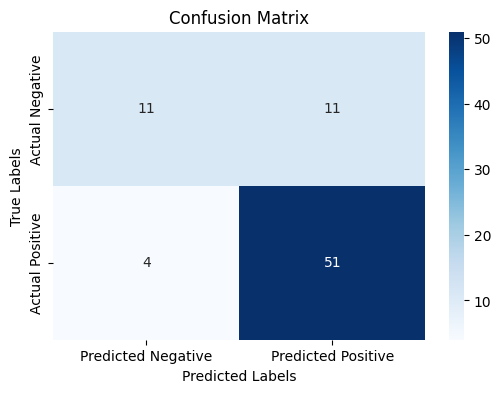

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 np.float64(0.8421487603305785),
 'ROC AUC Score',
 {'0': {'precision': 0.7333333333333333,
   'recall': 0.5,
   'f1-score': 0.5945945945945946,
   'support': 22.0},
  '1': {'precision': 0.8225806451612904,
   'recall': 0.92727

In [95]:
model, metric_score, metric_name, report, x_train, y_train, x_test, y_test = xgboost_classification(x, y, metric="aucroc")
model, metric_score, metric_name, report

#### PDP

[used Gemini 2.5 flash to generate a wrapper to get the right shape of the output probabilities]

In [41]:
class ProbabilityWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        # Ensure the output is in the shape (n_samples, 2) for binary classification
        proba = self.model.predict_proba(X)
        if proba.shape[1] == 1:
            # If predict_proba returns only one column, assume it's the probability of the positive class
            # and add a column for the probability of the negative class (1 - proba)
            return np.hstack([1 - proba, proba])
        return proba

# Create an instance of the wrapper
wrapped_model = ProbabilityWrapper(model)

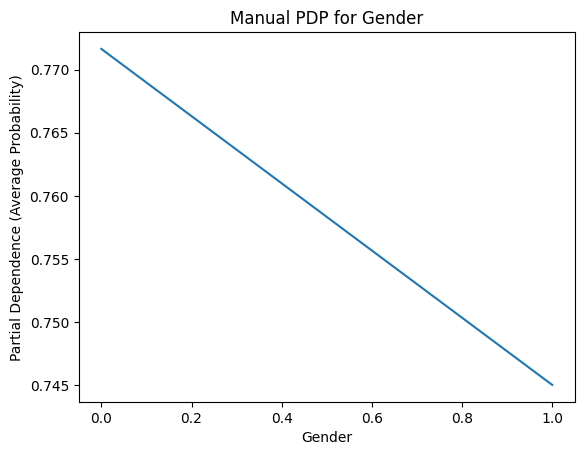

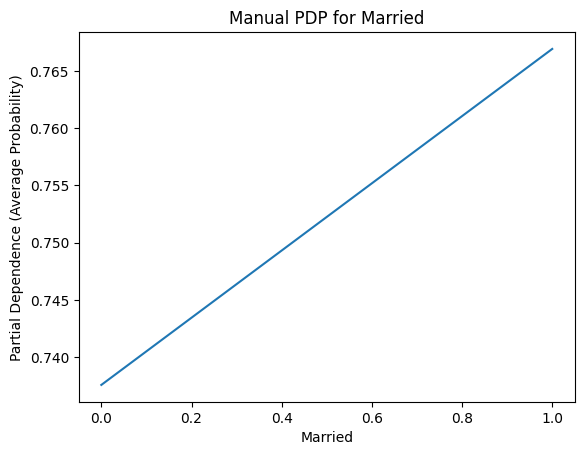

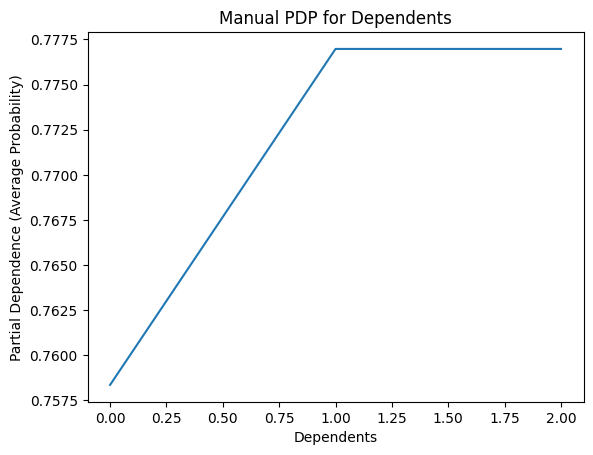

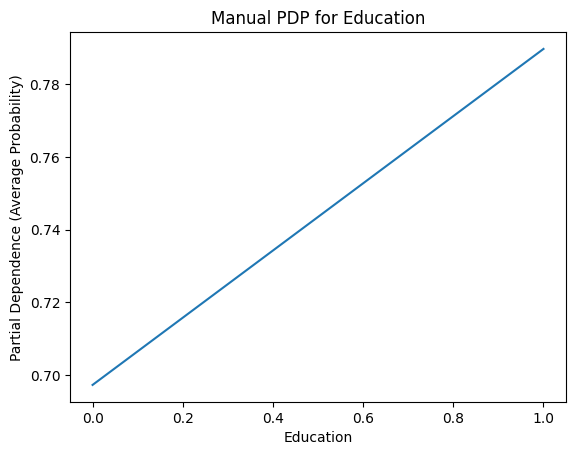

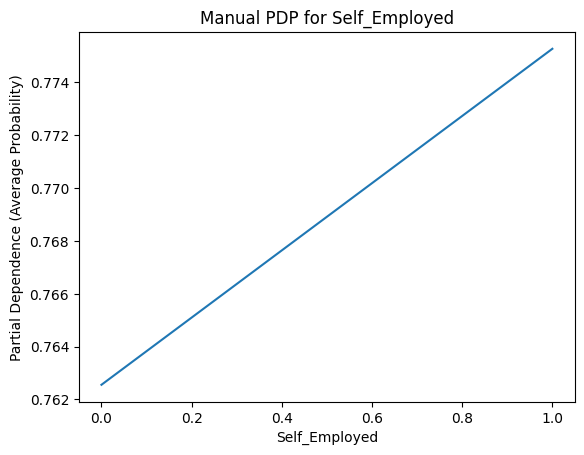

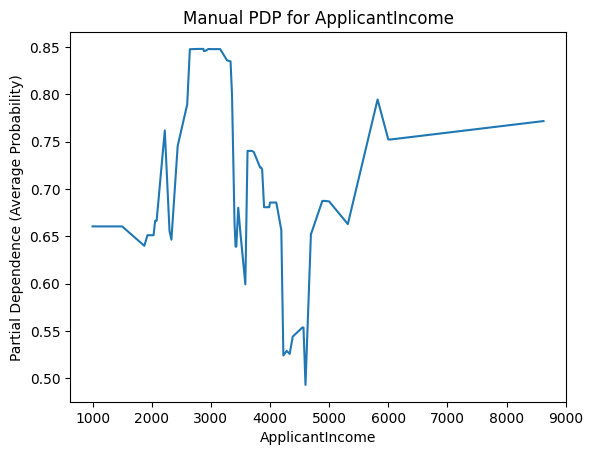

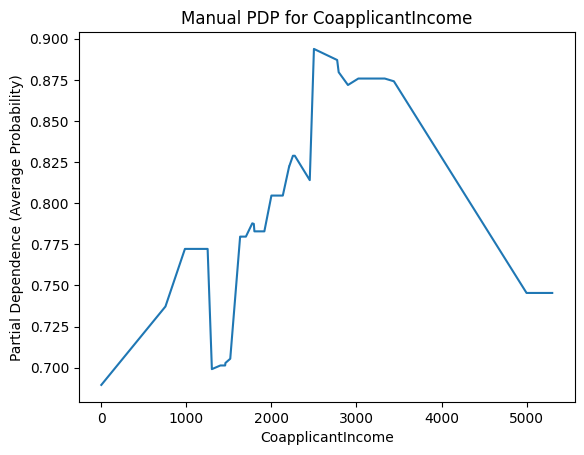

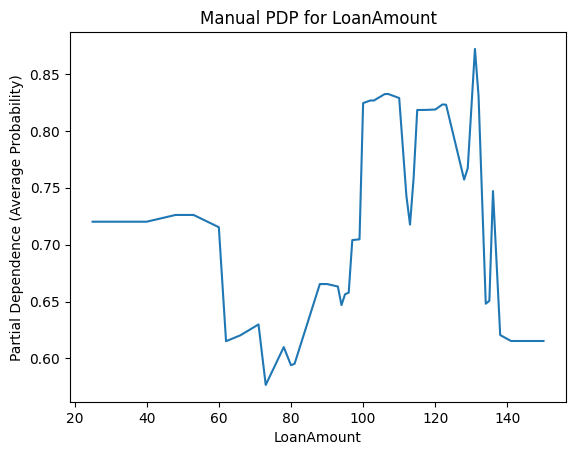

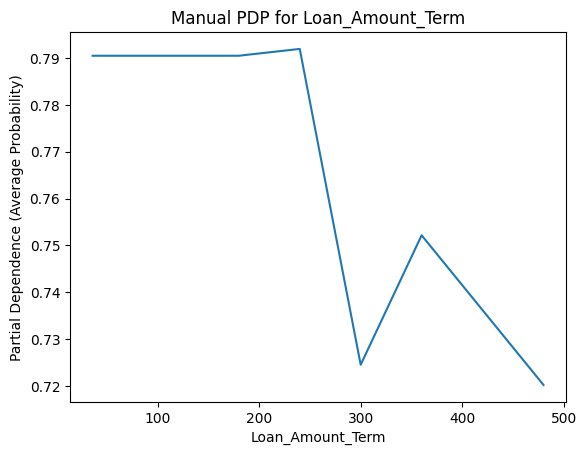

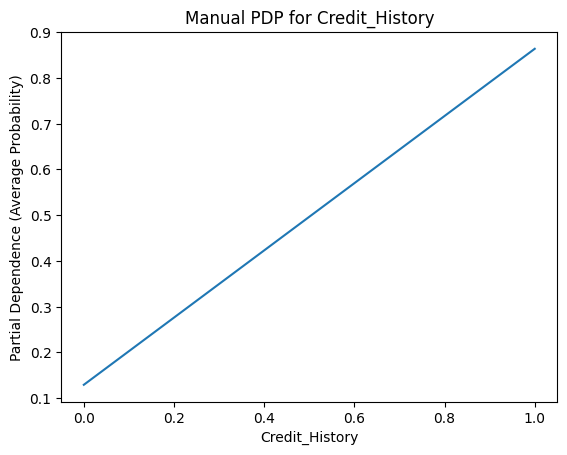

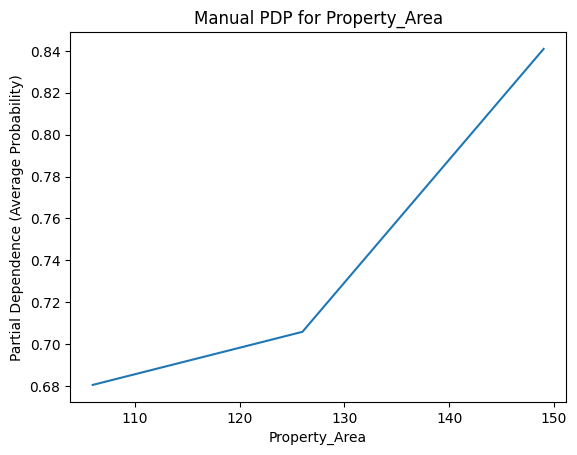

In [56]:
from sklearn.inspection import partial_dependence

# Define a prediction function that returns probabilities for the positive class
def predict_proba_positive(X):
    return wrapped_model.predict_proba(X)[:, 1]

# Manual calculation and plotting of PDP for all features

for feature_name in x_test.columns:
    unique_values = x_test[feature_name].unique()
    pdp_values = []

    for value in unique_values:
        x_test_copy = x_test.copy()
        x_test_copy[feature_name] = value
        # Get the average predicted probability for the positive class
        avg_prediction = wrapped_model.predict_proba(x_test_copy)[:, 1].mean()
        pdp_values.append(avg_prediction)

    # Sort values for plotting
    sorted_indices = np.argsort(unique_values)
    sorted_values = unique_values[sorted_indices]
    sorted_pdp_values = np.array(pdp_values)[sorted_indices]

    plt.plot(sorted_values, sorted_pdp_values)
    plt.xlabel(feature_name)
    plt.ylabel('Partial Dependence (Average Probability)')
    plt.title(f'Manual PDP for {feature_name}')
    plt.show()

From the above plots, the following can be observed:
1. For gender, being male generally incrases probability of class 1.

2. For marriage status, education, self employment, and credit history, going from "No" to "Yes" leads to higher probability of class 1.

3. For dependents, there is a difference (increased probability) going from 0 to 1, but no change whatsoever from 1 to 2, indicating that having dependents (not the number of them) is the key to determining class 1 probability.

4. Applicant income shows some wild trends. It looks like the curve has dramatic rises and falls as the income increases, but in general, after about the 4500 mark, there is an overall upward trend.

5. For co-applicant income, the probability of class 1 increases much until just under the 3000 mark, after which there is a decline in the probability.

6. For loan amount, the probability starts off steady going from 20 to almost 60, but after, there is a dip. Hits lowest probability at just over 70, and then it shoots up yet again, hitting a peak between 100 to 110, and continues to fluactuate up and down. The absolute highest probability of class 1 happens at a value of just above 130, before falling.

7. For loan amount term, the probability remains high (roughly 79%) before heading to a steep decline. Probability is lowest at 300, and goes though an upward peak

8. As property area increases, the probability of class 1 steadily inscreases throughout, albeit at different rates.


#### ICE

note that there has to be a separation of the categorical versus numerical features

In [81]:
cate, disc, nume = discover_categorical_and_numerical(x_train)
cate, disc, nume

There are 8 categorical, 0 discrete numerical, and 3 continuous numerical variables / features in the dataset


(['Gender',
  'Married',
  'Dependents',
  'Education',
  'Self_Employed',
  'Loan_Amount_Term',
  'Credit_History',
  'Property_Area'],
 [],
 ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'])

[I ran into quite a bit of problem with generating these graphs using the direct code from the course repo so I ended up using Grok 4 fast to generate the ICE plots]

In [99]:
from sklearn.inspection import PartialDependenceDisplay

def analyze_single_feature_fixed(model, x_test, feature_name):
    """
    Fixed version that uses feature indices and handles XGBoost reshaping issues
    - Only shows PDP and ICE plot
    """
    # Ensure x_test is all numeric
    x_test_numeric = x_test.select_dtypes(include=[np.number]).copy()

    if feature_name not in x_test_numeric.columns:
        print(f"Feature '{feature_name}' not found in numeric columns")
        return False

    # Get feature index (use indices instead of names for XGBoost)
    feature_idx = list(x_test_numeric.columns).index(feature_name)

    # Create single-panel figure
    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

    # Panel 1: PDP and ICE plot - Use feature index instead of name
    try:
        # Method 1: Try with feature index
        display = PartialDependenceDisplay.from_estimator(
            model, x_test_numeric,
            features=[feature_idx],  # Use index instead of name
            kind='both',
            ax=ax1,
            centered=True,
            grid_resolution=20,  # Reduced for stability
            subsample=500,  # Reduced sample size
            n_jobs=1,  # Single thread to avoid parallel issues
            random_state=42,
            line_kw={"color": "red", "linewidth": 2},
            ice_lines_kw={"alpha": 0.1, "color": "blue"}
        )

        # Set labels after plotting
        ax1.set_xlabel(feature_name)
        ax1.set_ylabel('Partial Dependence')
        ax1.set_title(f'PDP and ICE: {feature_name}')
        ax1.grid(True, alpha=0.3)

    except Exception as pdp_error:
        print(f"PDP/ICE failed for {feature_name}: {pdp_error}")
        # Fallback: Try PDP only (no ICE)
        try:
            display = PartialDependenceDisplay.from_estimator(
                model, x_test_numeric,
                features=[feature_idx],
                kind='average',  # Just PDP line, no ICE
                ax=ax1,
                centered=True,
                grid_resolution=20,
                n_jobs=1,
                random_state=42,
                line_kw={"color": "red", "linewidth": 2}
            )
            ax1.set_xlabel(feature_name)
            ax1.set_ylabel('Partial Dependence')
            ax1.set_title(f'PDP Only: {feature_name}')
            ax1.grid(True, alpha=0.3)

        except Exception as fallback_error:
            print(f"Fallback PDP also failed: {fallback_error}")
            # Final fallback: Manual approximation
            ax1.text(0.5, 0.5, f'PDP Failed\n{str(pdp_error)[:50]}',
                    ha='center', va='center', transform=ax1.transAxes, fontsize=10)
            ax1.set_title(f'PDP Failed: {feature_name}', color='red')
            ax1.axis('off')

    plt.tight_layout()
    plt.show()
    return True

def analyze_multiple_features_fixed(model, x_test, feature_list=None):
    """
    Fixed version that handles XGBoost reshaping issues
    - Shows PDP/ICE plots for ALL features (no limit)
    """
    # Use all numeric features if none specified
    if feature_list is None:
        x_test_numeric = x_test.select_dtypes(include=[np.number])
        feature_list = x_test_numeric.columns.tolist()
        print(f"Using all {len(feature_list)} numeric features")

    # Filter to only numeric features that exist
    x_test_numeric = x_test.select_dtypes(include=[np.number])
    valid_features = [f for f in feature_list if f in x_test_numeric.columns]

    if not valid_features:
        print("No valid numeric features found")
        return 0

    print(f"Analyzing ALL {len(valid_features)} valid features")

    successful_plots = 0
    for i, feature in enumerate(valid_features):
        print(f"Plotting {i+1}/{len(valid_features)}: {feature}")

        try:
            success = analyze_single_feature_fixed(model, x_test_numeric, feature)
            if success:
                successful_plots += 1
            else:
                print(f"Failed to plot {feature}")
        except Exception as e:
            print(f"Error processing {feature}: {e}")

    print(f"Completed {successful_plots} successful plots out of {len(valid_features)} total features")
    return successful_plots

# Alternative: Simple PDP-only version (most stable) - shows all features
def simple_pdp_only(model, x_test, feature_list=None, n_cols=3):
    """
    Simple PDP-only plots (no ICE) - most stable option
    - Shows ALL features in a grid layout
    """
    x_test_numeric = x_test.select_dtypes(include=[np.number])

    if feature_list is None:
        feature_list = x_test_numeric.columns.tolist()
        print(f"Using all {len(feature_list)} numeric features")
    else:
        # Filter to only valid features
        valid_features = [f for f in feature_list if f in x_test_numeric.columns]
        feature_list = valid_features
        print(f"Using {len(feature_list)} valid features from specified list")

    if not feature_list:
        print("No valid features to plot")
        return None

    # Use feature indices for all valid features
    feature_indices = [list(x_test_numeric.columns).index(f) for f in feature_list]

    # Calculate grid dimensions to show all features
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    try:
        fig, ax = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

        # If single subplot, make it not an array
        if n_features == 1:
            ax = [ax]
        else:
            ax = ax.ravel()

        display = PartialDependenceDisplay.from_estimator(
            model, x_test_numeric,
            features=feature_indices,
            kind='average',  # Only PDP line, no ICE curves
            ax=ax,
            centered=True,
            n_cols=n_cols,
            grid_resolution=20,
            n_jobs=1,  # Single thread
            line_kw={"color": "red", "linewidth": 2}
        )

        # Set feature names as titles and hide empty subplots
        for i, axi in enumerate(ax):
            if i < n_features:
                feature_name = feature_list[i]
                axi.set_title(feature_name, fontweight='bold', fontsize=10)
                axi.grid(True, alpha=0.3)
            else:
                # Hide empty subplots
                axi.set_visible(False)

        plt.suptitle(f'Partial Dependence Plots (PDP Only) - All {n_features} Features',
                    fontsize=16, y=0.98)
        plt.tight_layout()
        plt.show()

        print(f"PDP plots generated successfully for all {n_features} features")
        return display

    except Exception as e:
        print(f"Batch PDP failed: {e}")
        # Fallback: plot individually
        print("Falling back to individual plots...")
        return analyze_multiple_features_fixed(model, x_test, feature_list)

Using all 11 numeric features
Analyzing ALL 11 valid features
Plotting 1/11: Gender
PDP/ICE failed for Gender: cannot reshape array of size 1 into shape (2)
Fallback PDP also failed: cannot reshape array of size 1 into shape (2)


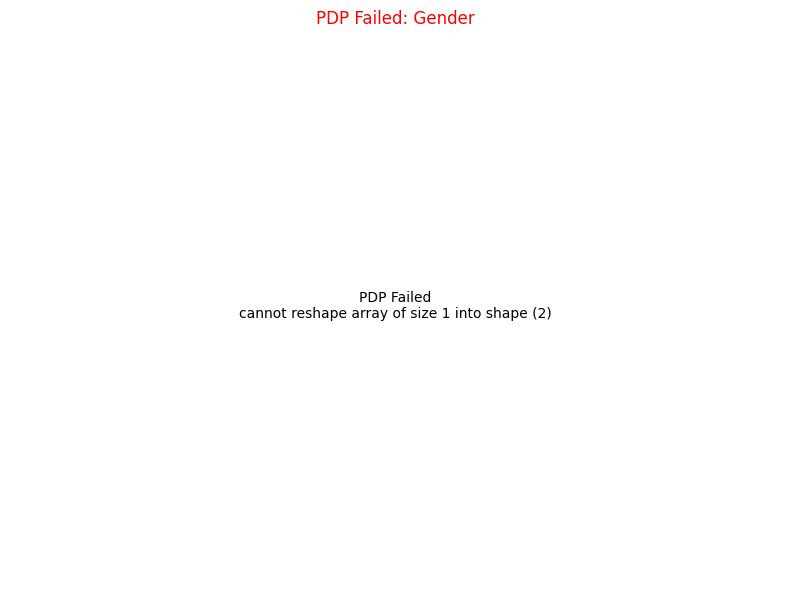

Plotting 2/11: Married
PDP/ICE failed for Married: cannot reshape array of size 1 into shape (2)
Fallback PDP also failed: cannot reshape array of size 1 into shape (2)


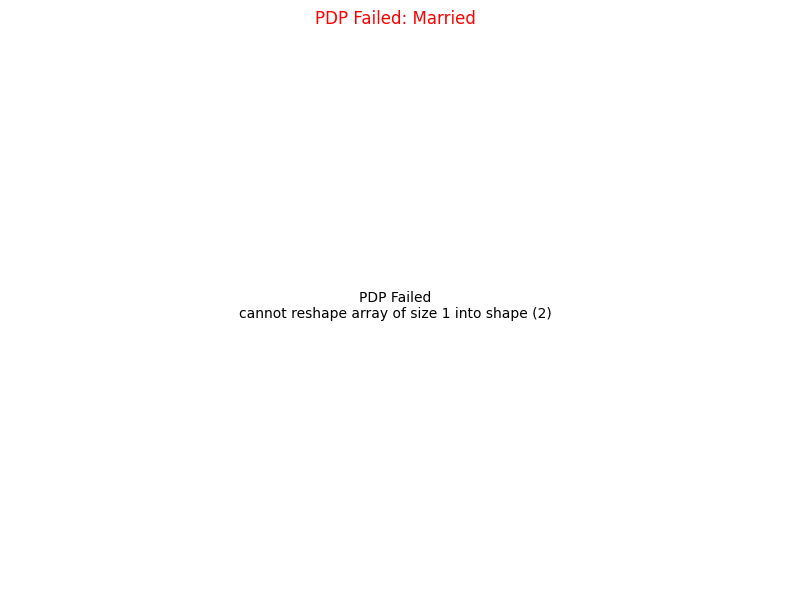

Plotting 3/11: Dependents


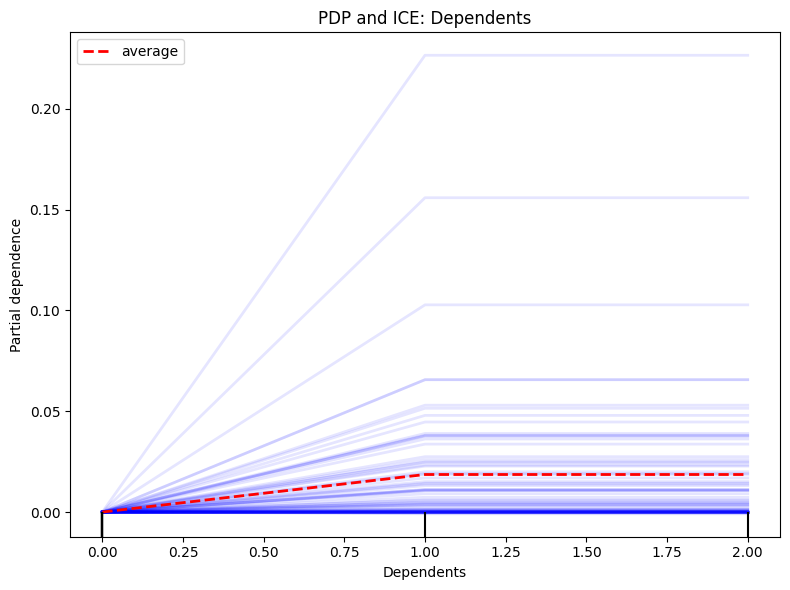

Plotting 4/11: Education
PDP/ICE failed for Education: cannot reshape array of size 1 into shape (2)
Fallback PDP also failed: cannot reshape array of size 1 into shape (2)


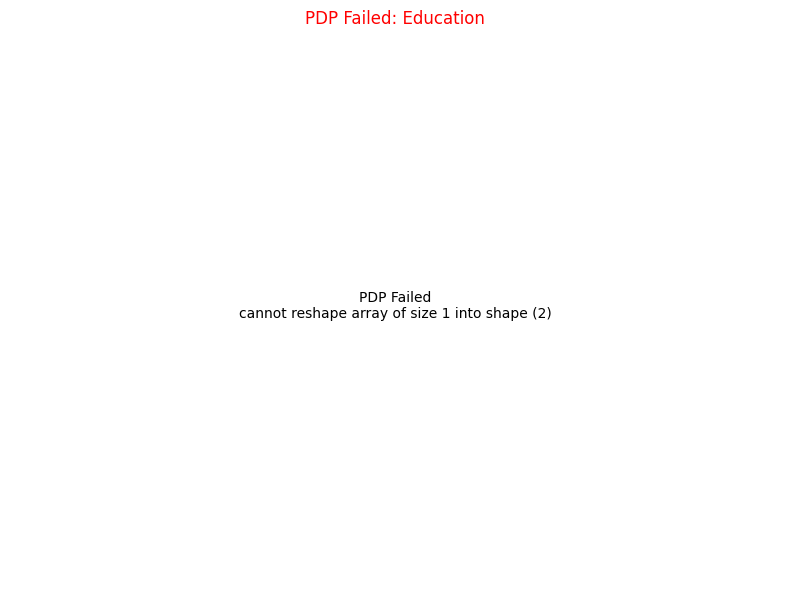

Plotting 5/11: Self_Employed
PDP/ICE failed for Self_Employed: cannot reshape array of size 1 into shape (2)
Fallback PDP also failed: cannot reshape array of size 1 into shape (2)


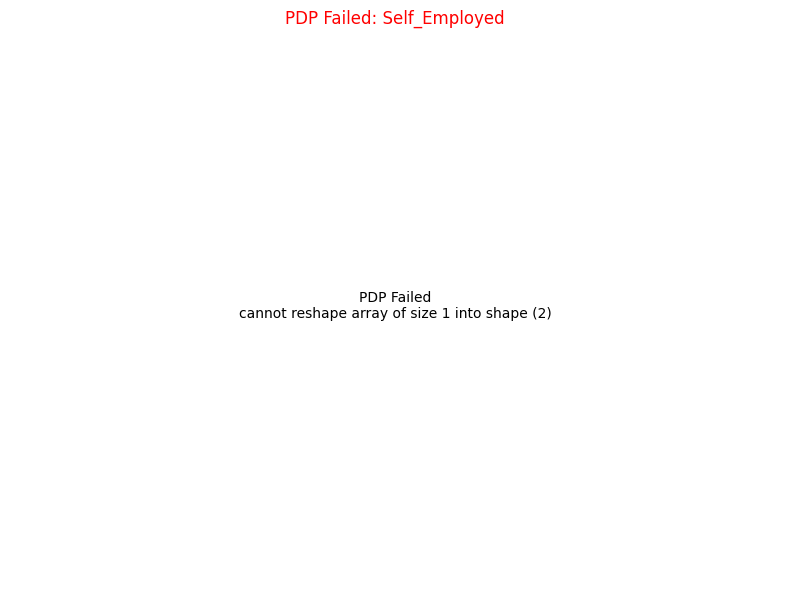

Plotting 6/11: ApplicantIncome


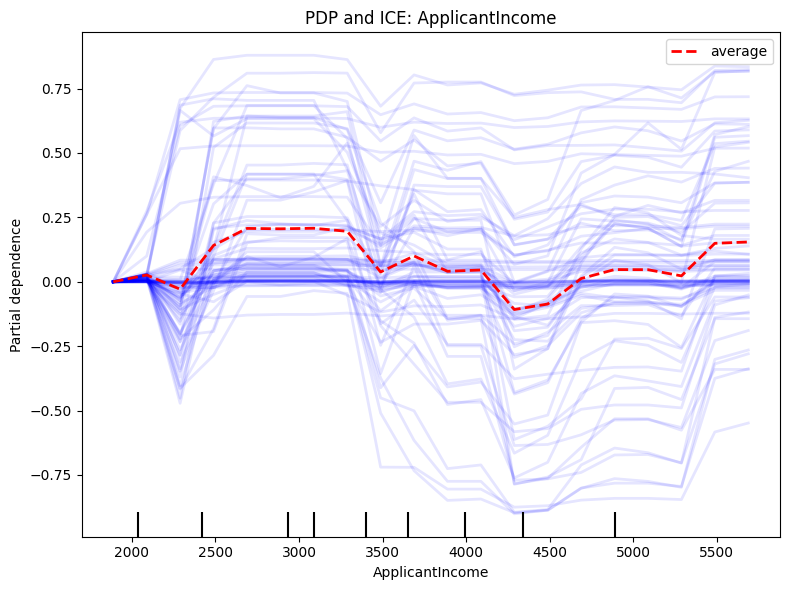

Plotting 7/11: CoapplicantIncome


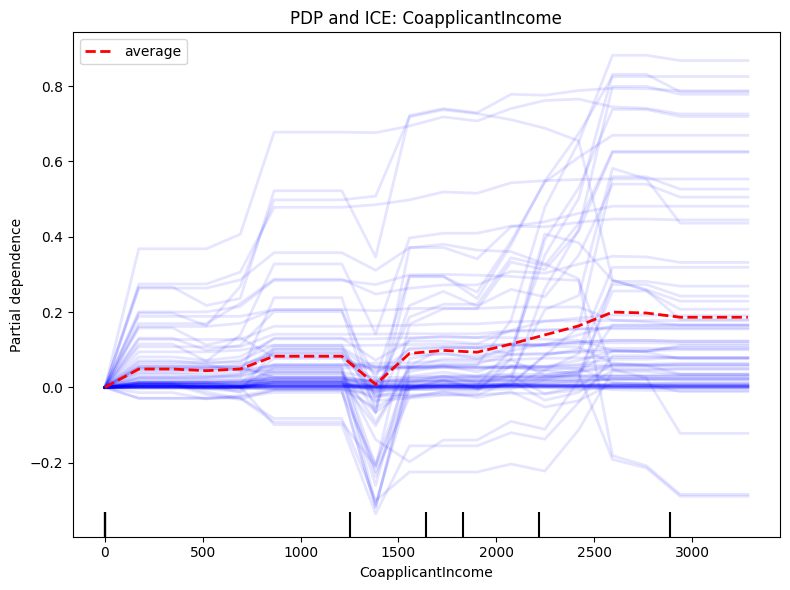

Plotting 8/11: LoanAmount


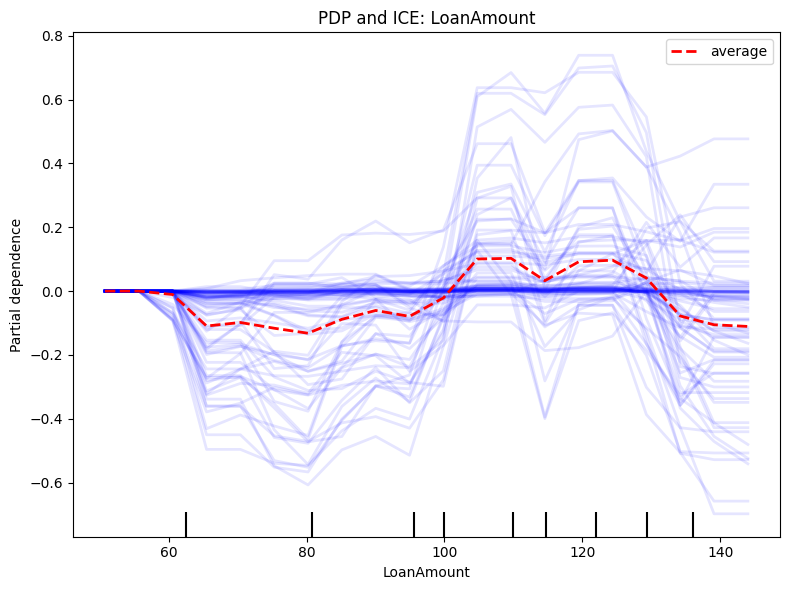

Plotting 9/11: Loan_Amount_Term


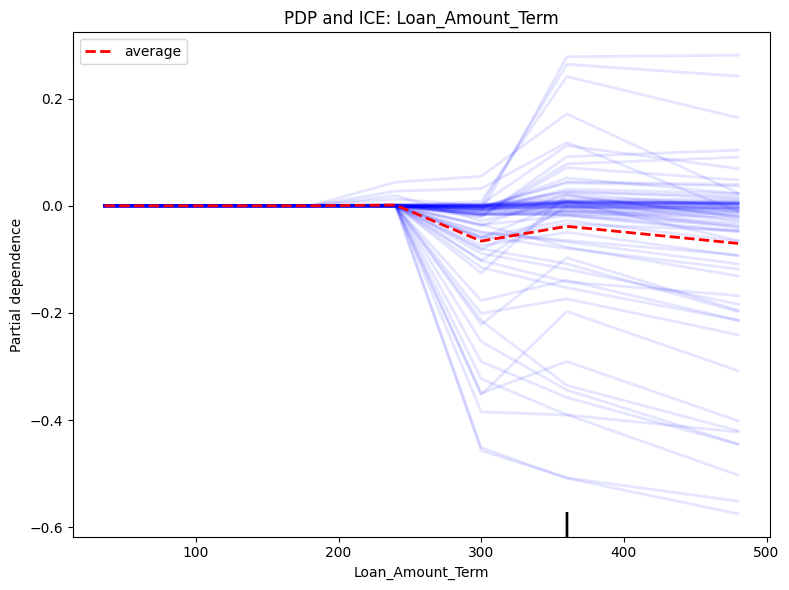

Plotting 10/11: Credit_History
PDP/ICE failed for Credit_History: cannot reshape array of size 1 into shape (2)
Fallback PDP also failed: cannot reshape array of size 1 into shape (2)


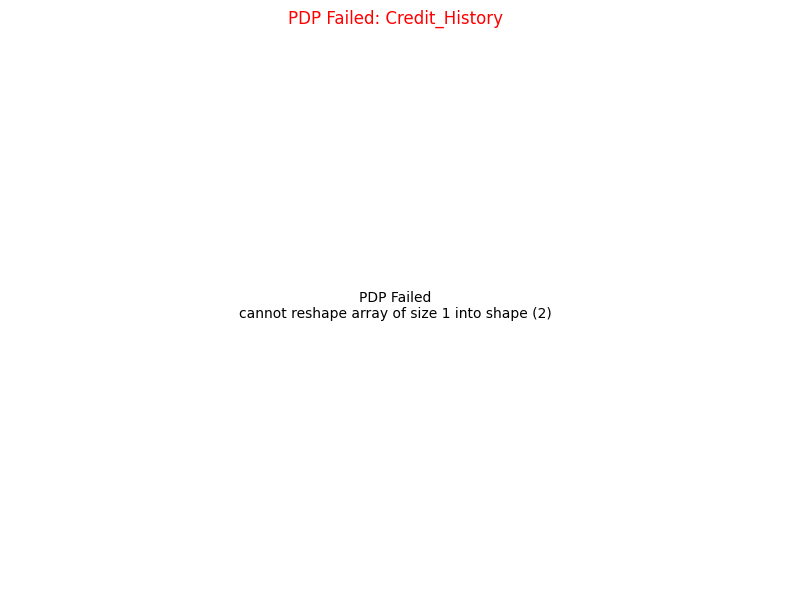

Plotting 11/11: Property_Area


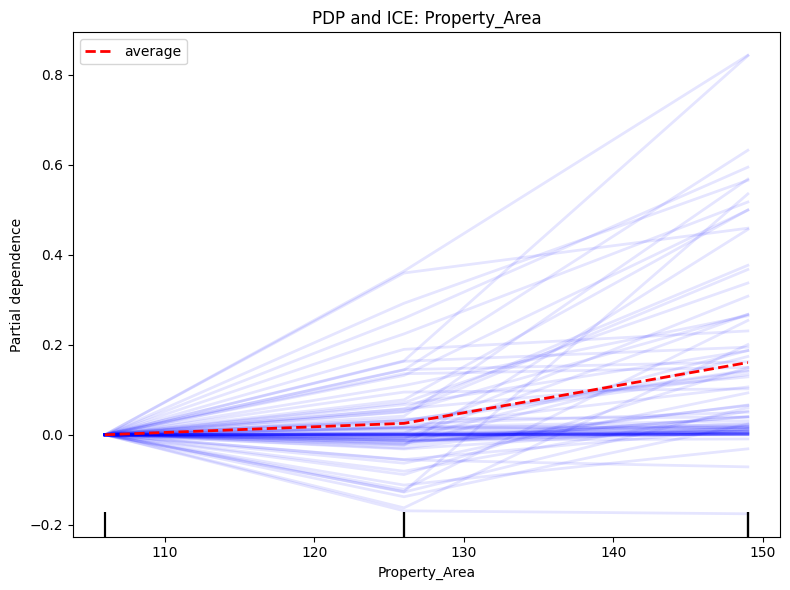

Completed 11 successful plots out of 11 total features


11

In [100]:
analyze_multiple_features_fixed(model, x_test)

Some plots above failed to generate. But from the ones that did generate successfully, here are the observations:

1. Dependents: Most instances show that there is a slight increase from 0 to 1, but a few instances have drastic effects.

2. Applicant income: generally increases until somewhere between 3000 and 3500. Hit the lowest at around 4300 mark before slowly climbing up again. There are some crossings, which could indicate feature interaction.

3. Coapplicant income: steady increase as values go up. Noticeably, there is a dip and recover for almost all instances from about 1250 to 1500, before going up again for many instances (but for some, there is a decrease in probability of class 1 as coapplicant income increases).

4. Loan amount: mostly in the negative range for most instances when loan amount increases from 0 to 100. There is an upward trend from 100 to 130 and after that, the probability of class 1 decreases.

5. Loan amount term: most instances show 0 up until around 250. After that, most instances show an overall decreasing trend.

6. Property area: most instances generally increase as property area increases, although some instances begin in the negative particial dependence, but still increase as property area rises.

#### ALE

In [63]:
!pip install PyALE

INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Continuous feature detected.
INFO:PyALE._ALE_generic:Continuous feature detected.
INFO:PyALE._ALE_generic:Continuous feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.
INFO:PyALE._ALE_generic:Discrete feature detected.


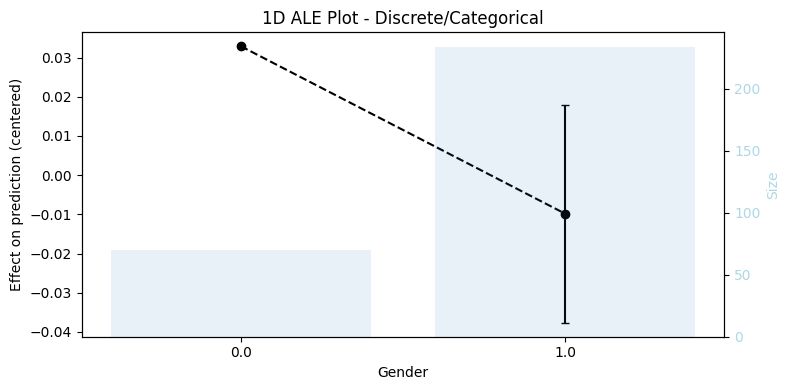

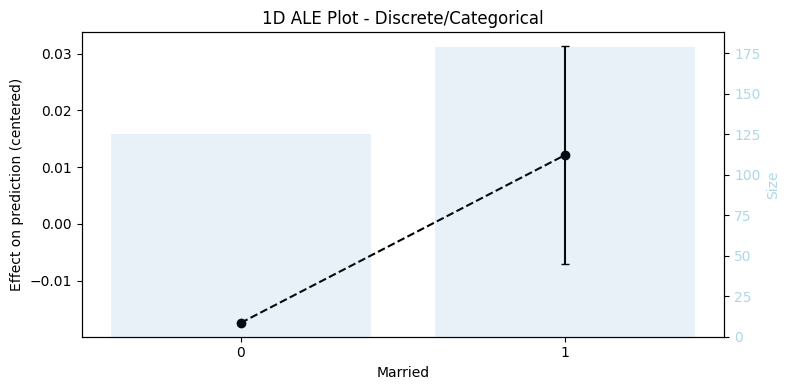

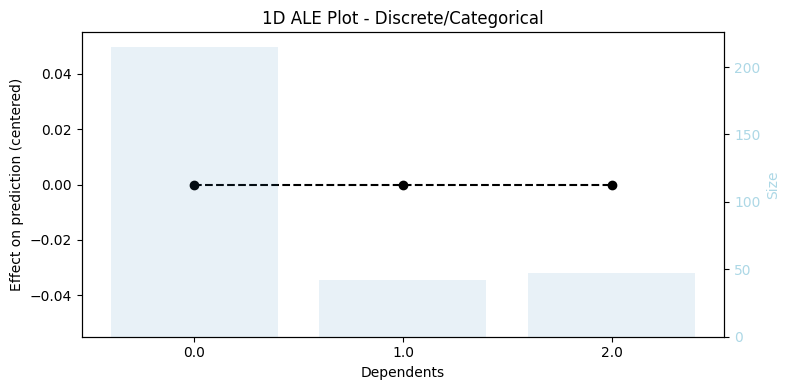

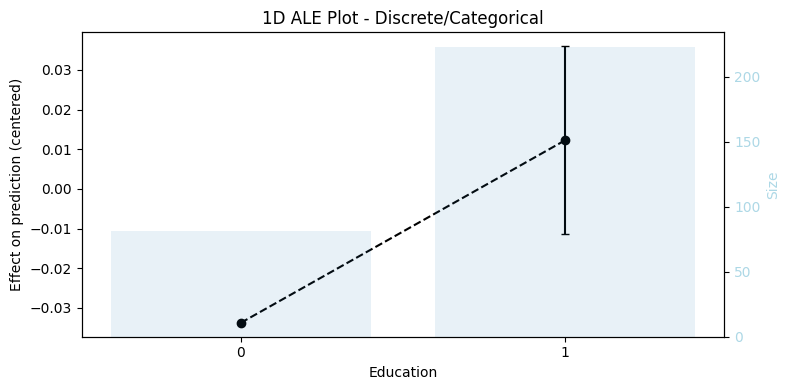

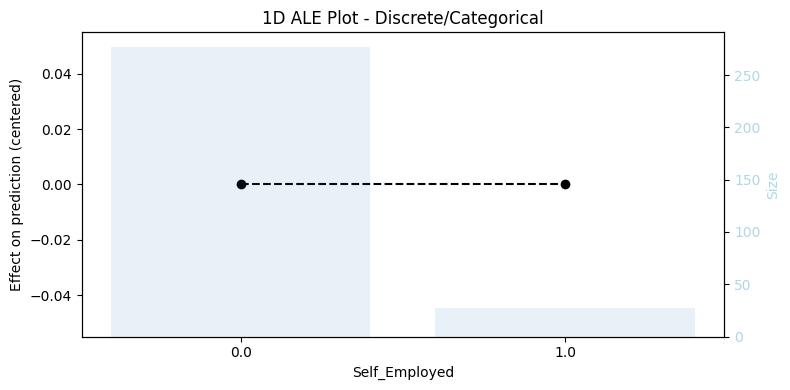

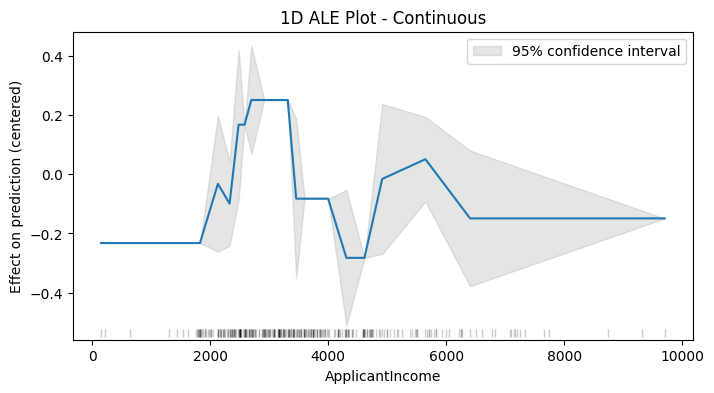

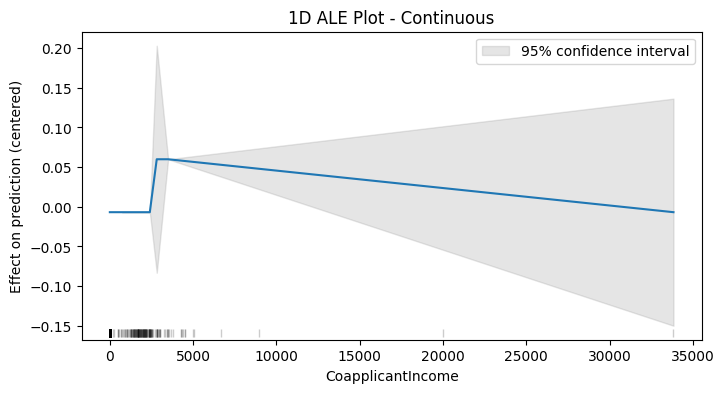

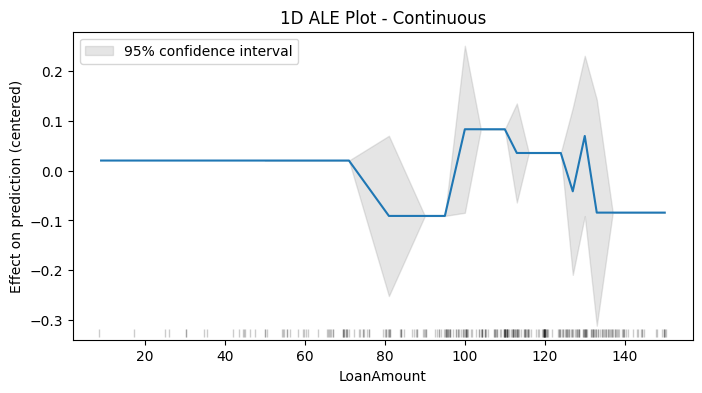

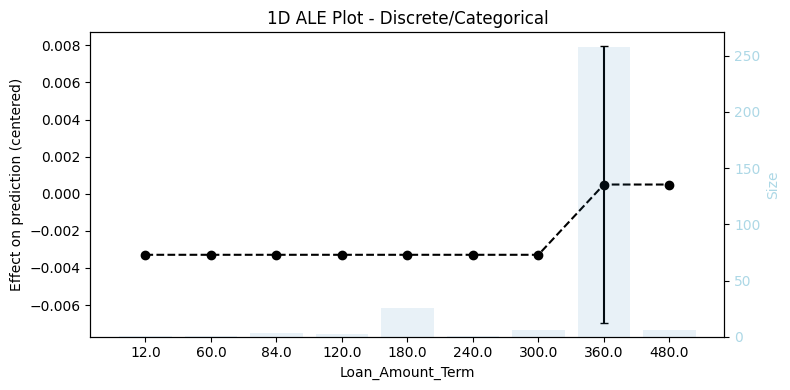

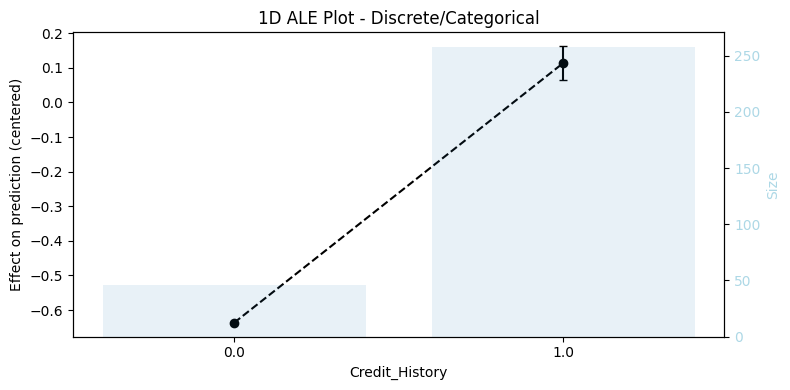

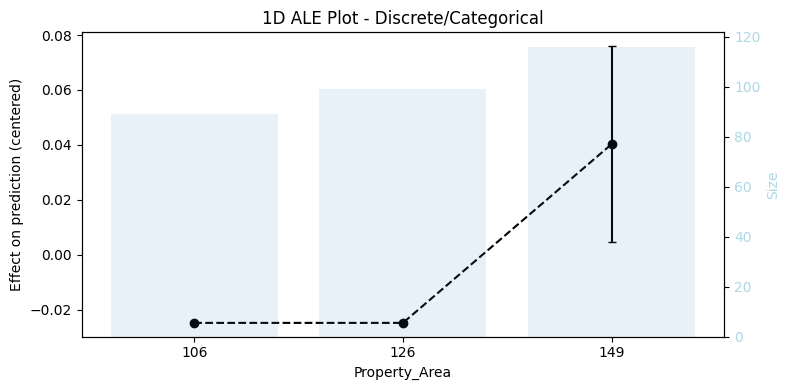

In [72]:
from PyALE import ale

for col in x_train.columns:
  ale_discr = ale(
      X=x_train,
      model=model,
      feature=[col],
      include_CI=True,
      C=0.95,
  )

For categorical / discrete features:
1. Gender: prediction is lower when gender = male. Prediciton is higher when gender = female.
2. Marriage: prediction is higher when marriage status is "yes" rather than "no". Both classes increase prediction.
3. Dependents: dependents = 0 increases prediction. dependents = 1 and dependents = 2 decreases prediction, moderately.
4. Education: education = 1 (having a college degree) increases prediciton, but lowers prediction when education = 0.
5. Self employed: increases prediction when self employed is 0. Decreases prediction when it is 1.
6. Loan amount term: increases prediciton the most when the loan amount term is 360.
7. Credit history: When credit history = 0, it lowers prediction, but when = 1, it increases prediction.
8. Property area: all 3 values increase prediction, but moving to higher values, prediction increases more.

For numerical features:
1. Applicant income: in general, there is an increase in prediction when value is high (6000 + compared to 0-2000), but, in the middle, there are ups and downs.
2. Coapplicant income: initially, higher income levels increase prediction but at some point less than 5000, higher values slowly decrease prediction.
3. Loan amount: initially, higher amounts have no effect (flat line) on prediction. There are some ups and downs as the amount increases, but after some point, hgiher values have negative effect on prediction.